## HW4

1. Скачайте 1079 геномов из 30 российских популяций с сайта http://
www.russiangenome.ru/
2. Для каждой пары геномов найдите IBD сегменты. Можете использовать
фазирование и поиск IBD-сегментов. Можете использовать поиск half-IBD сегментов
без фазирования.
3. Вычислите среднее количество общей суммы IBD / half-IBD сегментов между
популяциями. Визуализируйте в виде Heatmap.
4. Проанализируйте и опишите полученный результат. Сравните с PCA.

Начало тут такое же как и в ДЗ 2/3 - уже скачан датасет. 

#### Задание 1

 Скачал датасет и положил в DATA_PREFIX (ниже в коде)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import subprocess

import pandas as pd
import numpy as np

In [4]:
PLINK2 = Path("plink2_mac_arm64_20260228/plink2")
DATA_PREFIX = Path("biengi/biengi")
OUT_DIR = Path("biengi/results")
OUT_DIR.mkdir(exist_ok=True)

# Такая же утилита для прогона команд из ОС над бинарем - даёт передавать значения флагов и вывод в ячейку
def run_plink2(args):
    cmd = [str(PLINK2), *map(str, args)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("plink2 failed command on binary")
    if result.stdout:
        print(result.stdout)

    return result

#### Задание 2

Строим IBD-сегменты (над уже построенным qc_pruned.bed). Используем утилиту KING (Kinship-based INference for GWAS), там будут коэффициенты KINSHIP. Этот метод вычисляет коэффициент родства φ (тот же kinship), который монотонно связан с долей IBD-сегментов Для посчёта родства глазами надо обработать KINSHIP:

KINSHIP (φ) = (k2 + k1/2) / 2

Несвязанные:                    φ ≈ 0 (<0, значит также несвязанные, может быть характерно если датасет не из родственников, в общем как у нас)

2-я степень:                    φ ≈ 0.0625–0.125

1-я степень:                    φ ≈ 0.125–0.25

Родитель-ребёнок/сиблинги:      φ ≈ 0.25


In [8]:
qc_pruned_king_prefix = OUT_DIR / "qc_pruned_king"
qc_pruned_prefix = OUT_DIR / "qc_pruned"

run_plink2([
    "--bfile", qc_pruned_prefix,
    "--make-king-table",
    "--out", qc_pruned_king_prefix,
    ]
)

PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/qc_pruned_king.log.
Options in effect:
  --bfile biengi/results/qc_pruned
  --make-king-table
  --out biengi/results/qc_pruned_king

Start time: Sun May  3 22:27:51 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/results/qc_pruned.fam.
74666 variants loaded from biengi/results/qc_pruned.bim.
Note: No phenotype data present.
--make-king-table pass 1/1: Scanning for rare variants... 87done.
0 variants handled by initial scan (74666 remaining).

--make-king-table pass 1/1: 0 variants complete.
--make-king-table pass 1/1: 1536 variants complete.
--make-king-table pass 1/1: 3072 variants complete.
--make-king-table pass 1/1: 4608 variants complete.
--make-king-table 

CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/results/qc_pruned', '--make-king-table', '--out', 'biengi/results/qc_pruned_king'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/qc_pruned_king.log.\nOptions in effect:\n  --bfile biengi/results/qc_pruned\n  --make-king-table\n  --out biengi/results/qc_pruned_king\n\nStart time: Sun May  3 22:27:51 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/results/qc_pruned.fam.\n74666 variants loaded from biengi/results/qc_pruned.bim.\nNote: No phenotype data present.\n--make-king-table pass 1/1: Scanning for rare variants... 0%\x08\x0887%\x08\x08\x08done.\n0 variants handled by initial scan (74666 remaining).\n

#### Задание 3

Вычисляем среднее общей суммы сегментов.

               #FID1               IID1               FID2               IID2   NSNP    HETHET      IBS0   KINSHIP
0  4461875510_R01C02  4461875510_R01C02  4461875510_R01C01  4461875510_R01C01  74614  0.146742  0.075790 -0.010354
1  4461875510_R02C01  4461875510_R02C01  4461875510_R01C01  4461875510_R01C01  74637  0.146938  0.073663 -0.002394
2  4461875510_R02C01  4461875510_R02C01  4461875510_R01C02  4461875510_R01C02  74631  0.146012  0.074741 -0.006525
3  4461875513_R02C02  4461875513_R02C02  4461875510_R01C01  4461875510_R01C01  74620  0.143862  0.075114 -0.011422
4  4461875513_R02C02  4461875513_R02C02  4461875510_R01C02  4461875510_R01C02  74614  0.144128  0.074959 -0.014352


               #FID1               IID1               FID2               IID2   NSNP    HETHET      IBS0   KINSHIP              FID_x              IID_x   POP1              FID_y              IID_y   POP2
0  4461875510_R01C02  4461875510_R01C02  4461875510_R01C01  4461875510_R01C01  74614  0.146742  0.07579

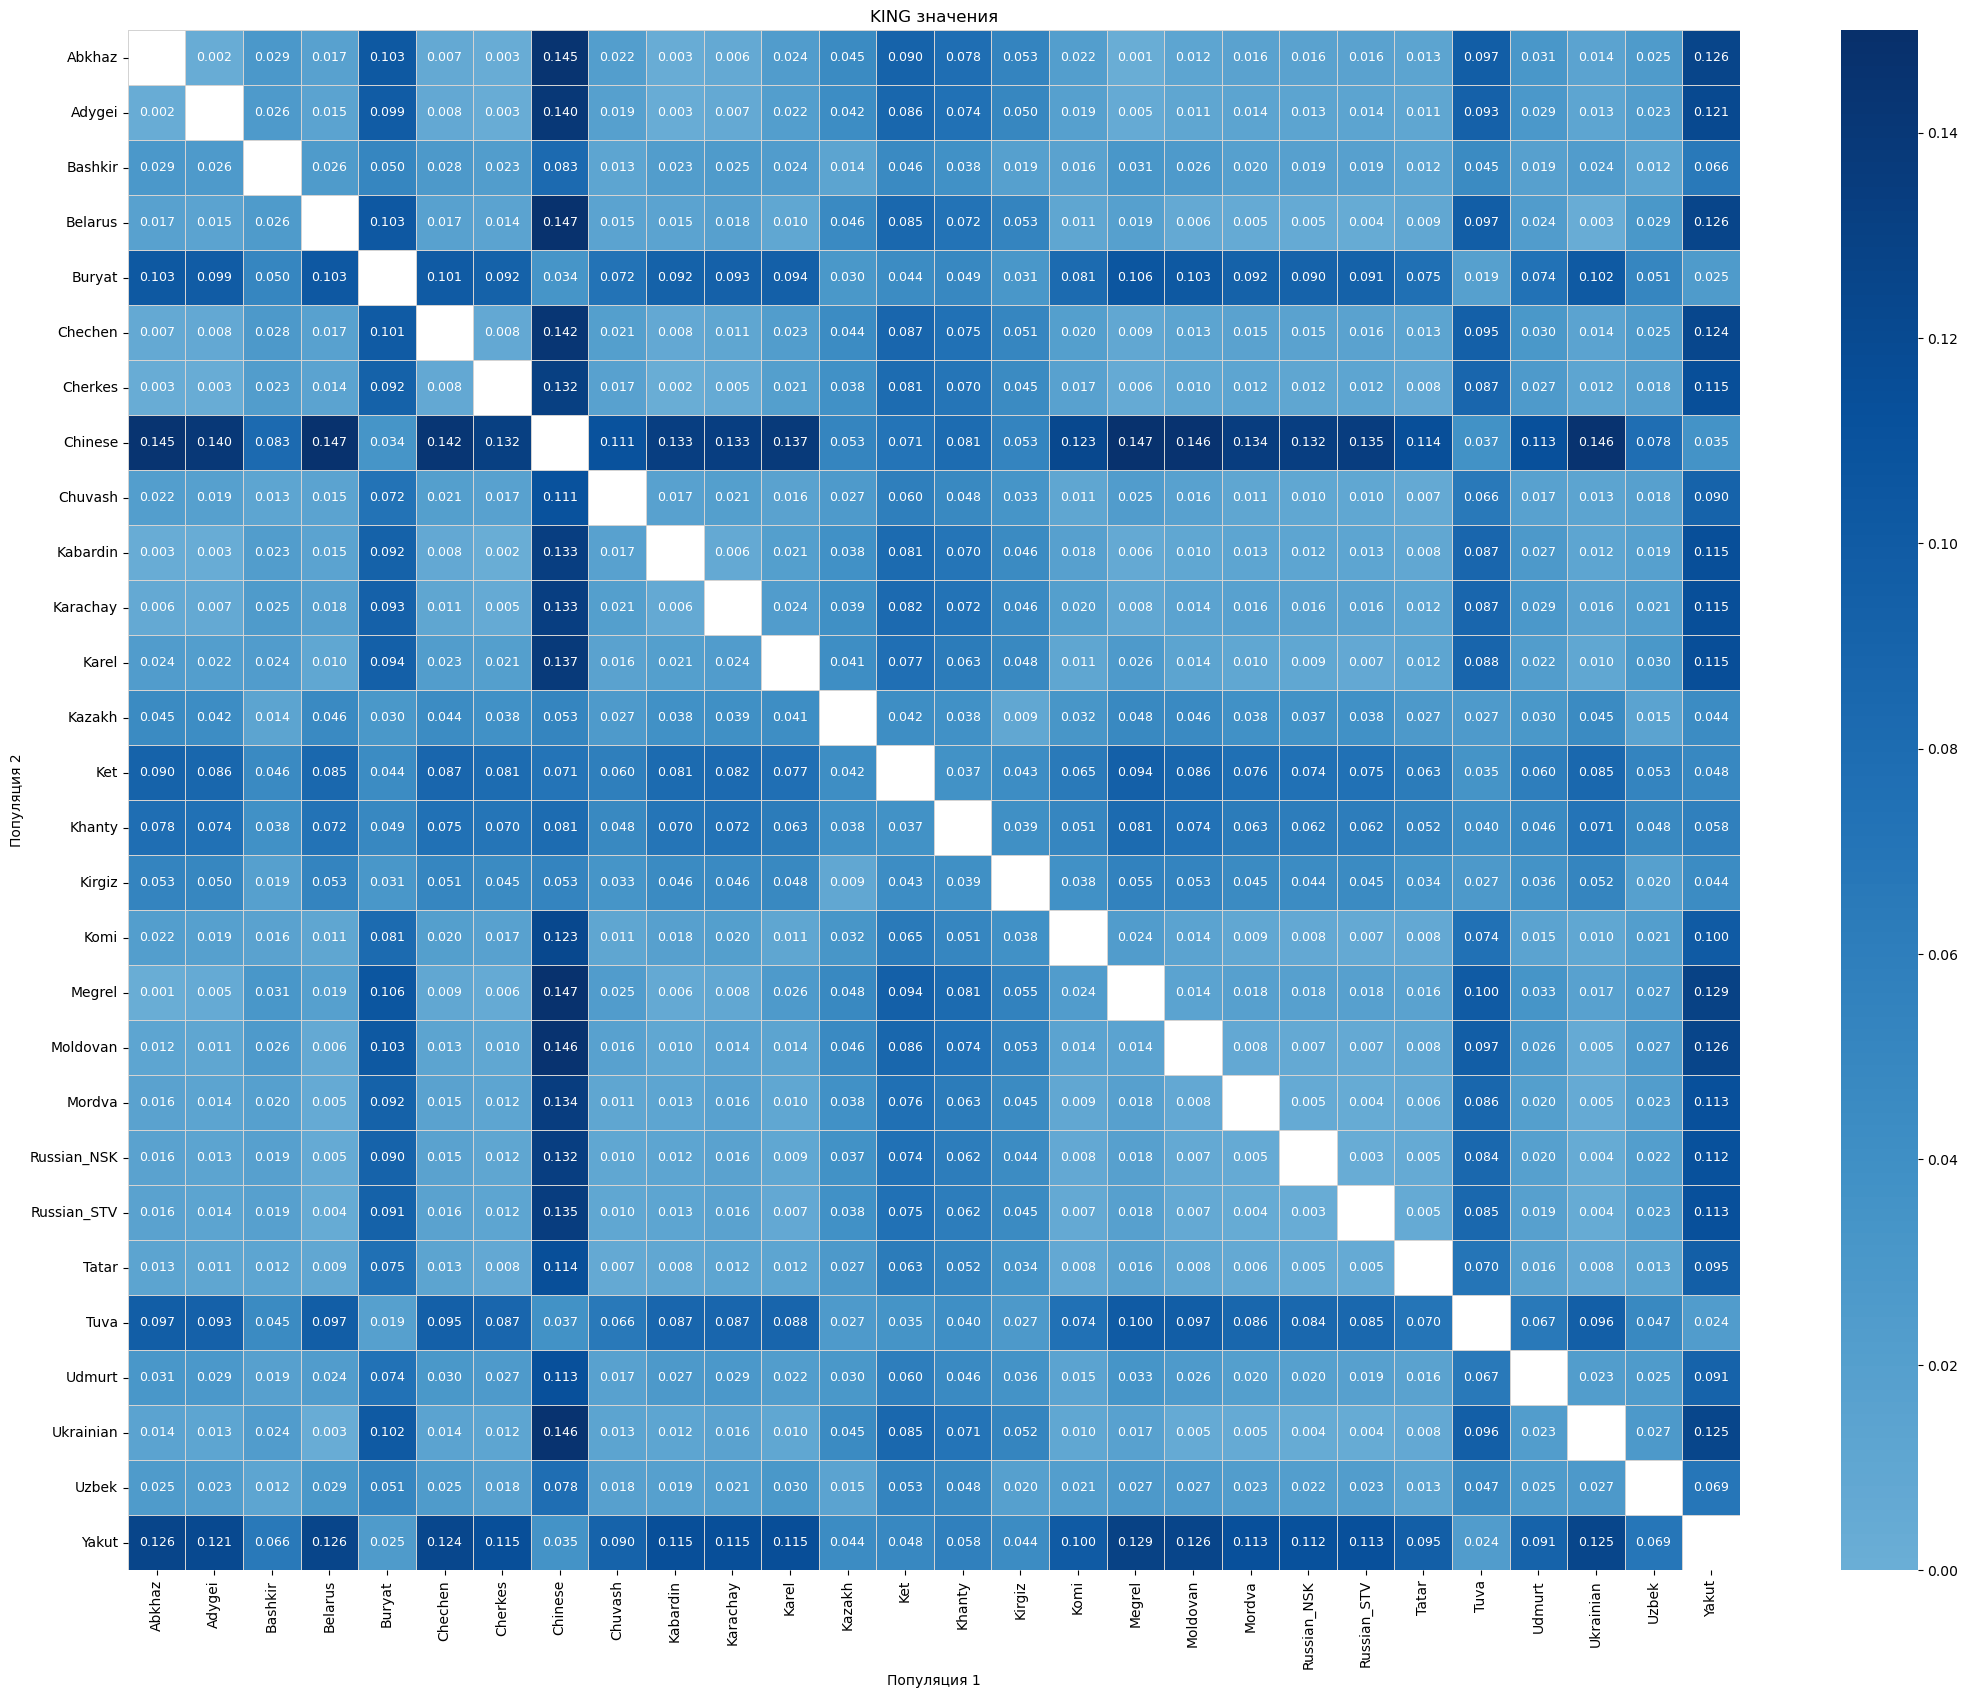

In [46]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

king = pd.read_csv(str(qc_pruned_king_prefix) + ".kin0", sep="\t")
king.columns = ["#FID1", "IID1", "FID2", "IID2", "NSNP", "HETHET", "IBS0", "KINSHIP"]
print(king.head())
print("\n")

pop_file = OUT_DIR / "populations.tsv"
pop = pd.read_csv(pop_file, sep="\t")
pop.columns = ["FID", "IID", "POP"]

merged = pd.merge(king, pop, left_on=["#FID1", "IID1"], right_on=["FID", "IID"])
merged.rename(columns={'POP': 'POP1'}, inplace=True)
merged = pd.merge(merged, pop, left_on=["FID2", "IID2"], right_on=["FID", "IID"])
merged.rename(columns={'POP': 'POP2'}, inplace=True)

print(merged.head())
print("\n")

# создаём зеркальные пары, так как изначально есть только в одну сторону
mirror = merged.rename(columns={
    '#FID1': 'FID2', 'IID1': 'IID2',
    'FID2': '#FID1', 'IID2': 'IID1',
    'POP1': 'POP2', 'POP2': 'POP1',
    'FID_x': 'FID_y', 'IID_x': 'IID_y',
    'FID_y': 'FID_x', 'IID_y': 'IID_x',
})

merged_sym = pd.concat([merged, mirror], ignore_index=True)

pop_matrix = merged_sym.groupby(["POP1", "POP2"])['KINSHIP'].mean().unstack()
pop_matrix = -pop_matrix
np.fill_diagonal(pop_matrix.values, np.nan)

plt.figure(figsize=(26, 20))
sns.heatmap(
    pop_matrix,
    fmt='.3f',
    annot=True,
    cmap='Blues',
    center=0,
    linewidths=0.5,
    linecolor='lightgrey',
    annot_kws={"size": 9},
    vmin=0,
    vmax=0.15,
)

plt.title('KING значения')
plt.xlabel('Популяция 1')
plt.ylabel('Популяция 2')
plt.show()


#### Интерпретация heatmap и детали измерений

Можно заметить, что меньшие по расстоянию популяции (более бело-голубые) и правда исторически и географически более связаны, примерно то же давали и прошлые методы и алгоритмы (hw2-3). Один из примеров - строка Yakut в самом низу - она показывает лучшую близость с Buryat, Chinese, Tuva (топ3 по уменьшению расстояния).

Сам по себе KINSHIP - это безмерный коэффициент родства, по факту это метод поиска half-IDB сегментов *БЕЗ ФАЗИРОВАНИЯ*, нельзя выразить в сМ. В общем это не совсем сумма длин сегментов, но оно коррелирует и растёт монотонно с этим значением (чем больше суммарная длина IBD-сегментов, тем выше φ). В итоге на хитмапе качественно это одно и то же. Есть еще --genome в plink'е, но тот работает и считает суммы IBS вместо IBD, что нам не подходит.

#### Задание 4

Анализ общей картина на популяциях и сравнительно с PCA. Далее код из 2 дз скопировал, чтобы сравнить визуальные "кластеры" похожих популяций с тем, что вышло по хитмпапу.

In [40]:
def plot_pca(pca_metadata, left_component_num = "PC1", right_component_num = "PC2"):
    # Выделяем центры популяций
    centers = (
        pca_metadata
        .groupby("population")[[left_component_num, right_component_num]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(15, 11))

    # Рисуем графички
    for _, df_pop in pca_metadata.groupby("population"):
        plt.scatter(df_pop[left_component_num], df_pop[right_component_num], s=20, alpha=0.65)

    for _, row in centers.iterrows():
        plt.text(
            row[left_component_num],
            row[right_component_num],
            str(row["population"]),
            fontsize=12,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round", fc="white", alpha=0.3, ec="none")
        )

    plt.xlabel(left_component_num)
    plt.ylabel(right_component_num)
    plt.title("PCA популяций")
    plt.tight_layout()
    plt.show()

pca = pd.read_csv("biengi/results/pca.eigenvec", sep=r"\s+", header=None)
pca.columns = ["FID", "IID", "PC1", "PC2", "PC3", "PC4", "PC5"]

# метаданные, где есть разметка по популяции, полу, родству
meta = pd.read_csv("biengi/biengi.pedind", sep="\t", header=None)
meta.columns = ["FID", "IID", "father", "mother", "sex", "population"]

# Мержим
pca_meta = pca.merge(
    meta[["FID", "IID", "population"]],
    on=["FID", "IID"],
    how="left"
)

# политика заполнения NaN невалидных значений
pca_meta["PC1"] = pd.to_numeric(pca_meta["PC1"], errors="coerce")
pca_meta["PC2"] = pd.to_numeric(pca_meta["PC2"], errors="coerce")
pca_meta["PC3"] = pd.to_numeric(pca_meta["PC3"], errors="coerce")
pca_meta["PC4"] = pd.to_numeric(pca_meta["PC4"], errors="coerce")
pca_meta["PC5"] = pd.to_numeric(pca_meta["PC5"], errors="coerce")

pca_meta.dropna(inplace=True)

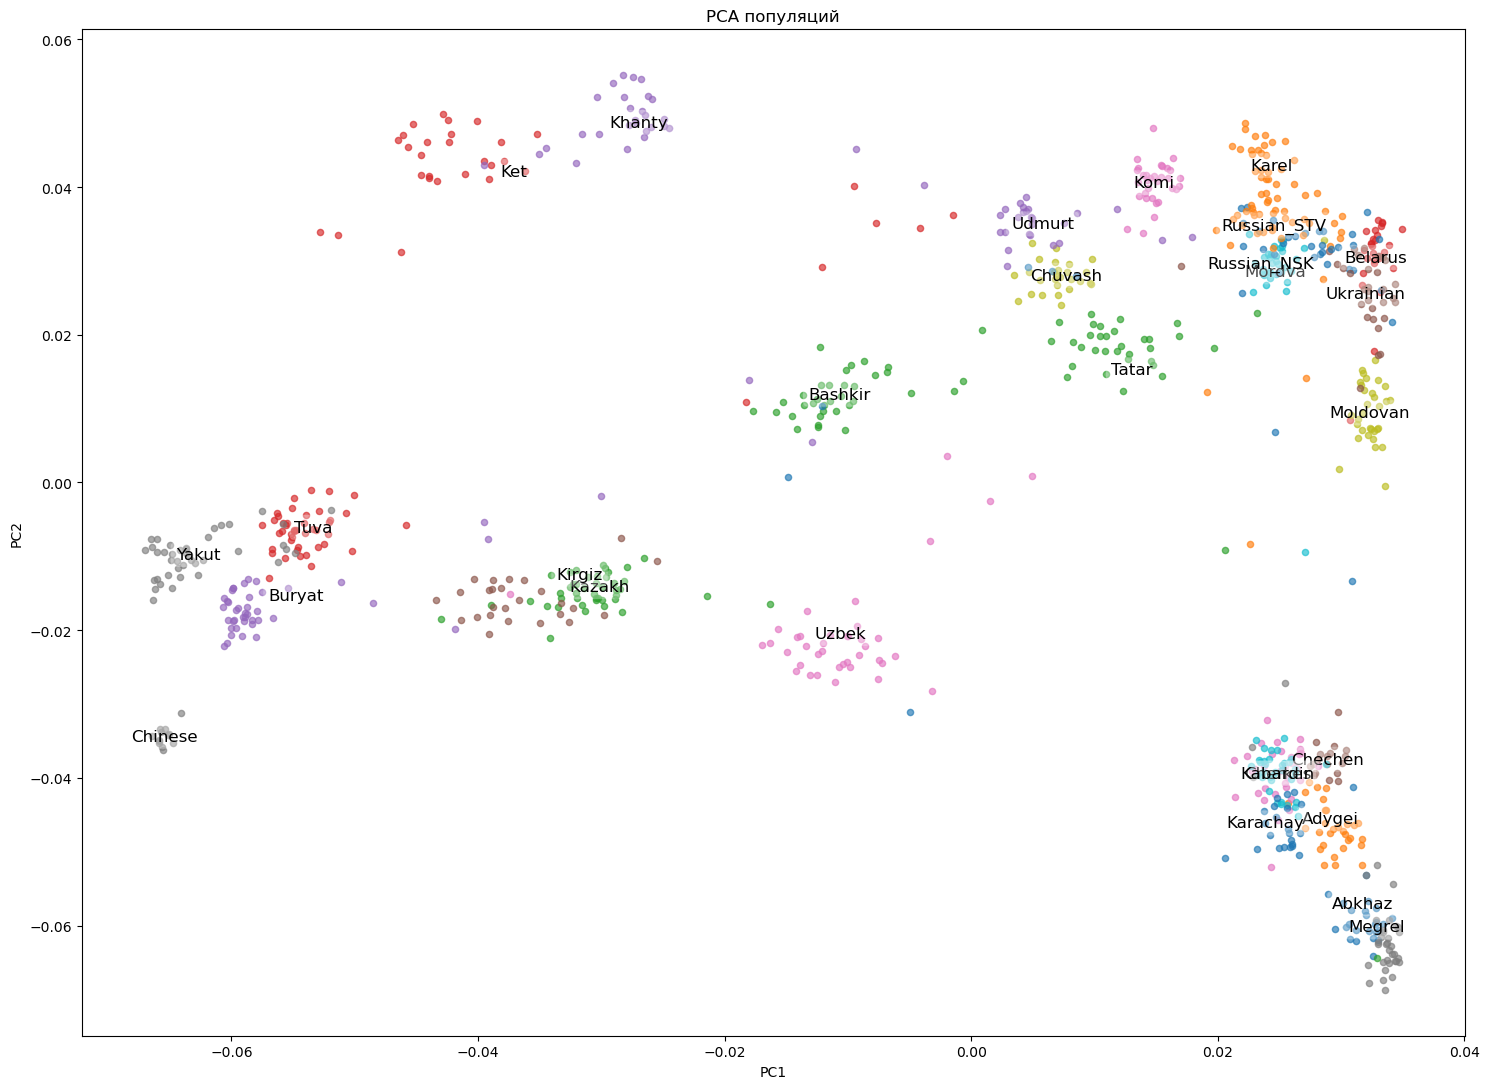

In [41]:
plot_pca(pca_meta, "PC1", "PC2")

Матрица KINSHIP и PCA отражают одну и ту же популяционную структуру, но в разных представлениях. На PCA (PC1 vs PC2) популяции разделяются на три основных кластера: восточноевропейский (Belarus, Ukrainian, Russian, Karel, Mordva, Komi), северокавказский (Adygei, Kabardin, Cherkes, Chechen, Megrel, Abkhaz) и центральноазиатско-сибирский (Chinese, Yakut, Buryat, Tuva + не так далеко Kazakh, Kirgiz). Тюркские народы Поволжья (Bashkir, Tatar, Chuvash) занимают промежуточное положение между европейским и азиатским кластерами.

На heatmap KINSHIP эти же кластеры проявляются как блоки с меньшими значениями (светлее) внутри кластера и более отрицательными (темнее) между кластерами. Наибольшая генетическая дистанция — между восточноазиатскими популяциями (Chinese, Yakut) и европейскими - inverse KINSHIP = 0.13 до 0.15 (при условии инвертации KINSHIP), что соответствует максимальному расстоянию по PC1 на PCA. Наименьшая дистанция — между `Russian_NSK` и `Russian_STV` (inv KINSHIP = 0.003), что согласуется с их практически совпадающим положением на PCA.

Таким образом, оба метода дают согласованную картину: основная ось генетической изменчивости в выборке — это ось "европейский-восточноазиатский", а кавказские популяции образуют отдельный кластер, отличный от обоих полюсов.
